<a href="https://colab.research.google.com/github/AryaPutra-182/2318034-EkstraksiFiturTekstur/blob/main/2318034AryaPutraKlasifikasiCitraGitarElektrik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Import Library

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 3. Tentukan Path Dataset

In [3]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset gitar/dataset" "/content/"

In [4]:
dataset_path = "/content/dataset"

train_dir = dataset_path + "/train"
valid_dir = dataset_path + "/valid"
test_dir = dataset_path + "/test"

# 4. Preprocessing Data

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2443 images belonging to 7 classes.
Found 1318 images belonging to 7 classes.
Found 654 images belonging to 7 classes.


# 5. Membuat Model MobileNetV2

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# 6. Tambahkan Layer Klasifikasi

In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(
    7,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

# 7. Compile Model

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 8. Training

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30
)

Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 800ms/step - accuracy: 0.2599 - loss: 1.9574 - val_accuracy: 0.4734 - val_loss: 1.4708
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 432ms/step - accuracy: 0.4675 - loss: 1.4213 - val_accuracy: 0.6510 - val_loss: 1.1719
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 420ms/step - accuracy: 0.5596 - loss: 1.1933 - val_accuracy: 0.7208 - val_loss: 0.9719
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 422ms/step - accuracy: 0.6390 - loss: 1.0196 - val_accuracy: 0.7625 - val_loss: 0.8388
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 444ms/step - accuracy: 0.6742 - loss: 0.9264 - val_accuracy: 0.7792 - val_loss: 0.7806
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 424ms/step - accuracy: 0.7090 - loss: 0.8293 - val_accuracy: 0.7951 - val_loss: 0.7061
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 425ms/step - accuracy: 0.7401 - loss: 0.7617 - val_accuracy: 0.8042 - val_loss: 0.6626
Epoch 8/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 441ms/step - accuracy: 0.7524 - loss: 0.7250 - val_accu

# 9. Evaluasi

In [10]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Accuracy: {accuracy*100:.2f}%")

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 619ms/step - accuracy: 0.8303 - loss: 0.4696
Test Accuracy: 83.03%


# 10. Grafik Akurasi

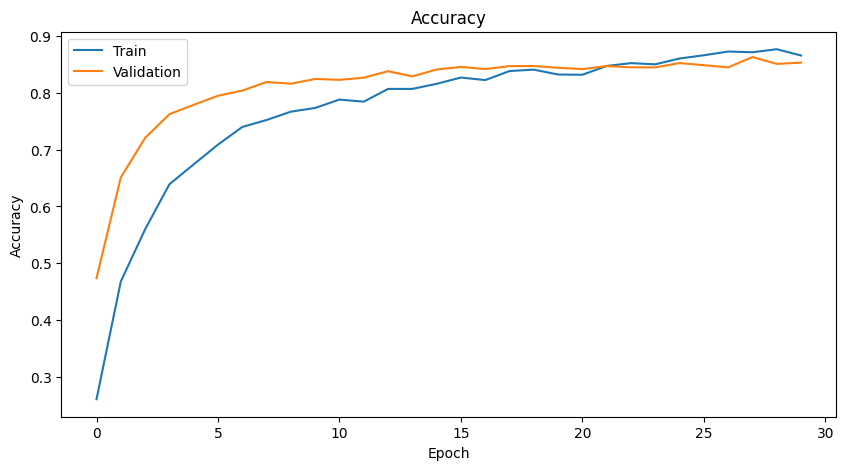

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

# 11. Simpan Model

In [12]:
model.save("mobilenetv2_gitar.h5")

# 12. Prediksi Satu Gambar

Saving billie-joe-armstrong-greenday-ethan-miller-1.jpg to billie-joe-armstrong-greenday-ethan-miller-1.jpg


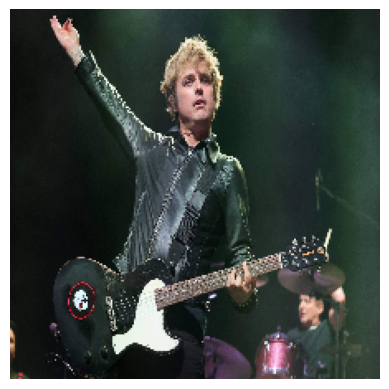

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Hasil Prediksi : SG
Confidence     : 54.52%


In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

uploaded = files.upload()

img_path = next(iter(uploaded))

img = image.load_img(
    img_path,
    target_size=(224,224)
)

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = [
    "Stratocaster",
    "Les Paul",
    "Telecaster",
    "Explorer",
    "Flying V",
    "SG",
    "ES"
]

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Hasil Prediksi : {predicted_class}")
print(f"Confidence     : {confidence:.2f}%")

# Grafik Accuracy

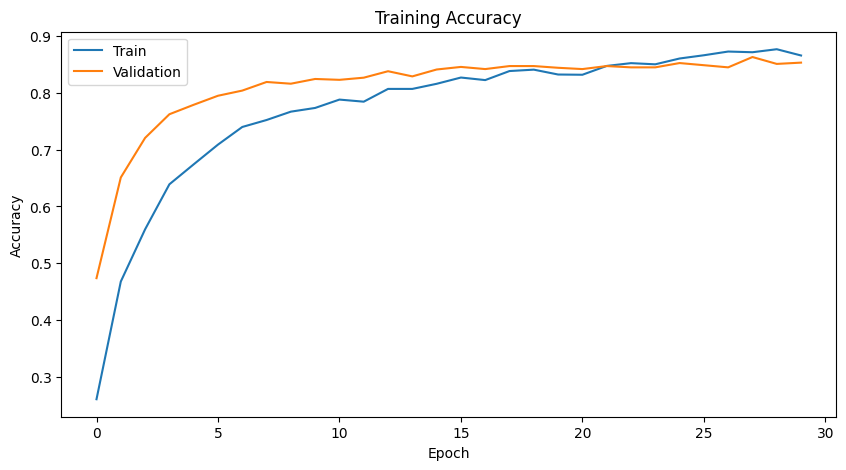

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

# Grafik Loss

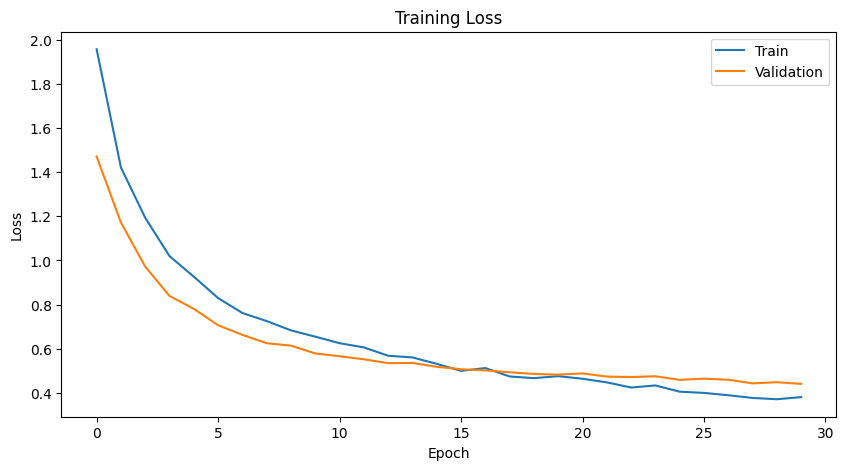

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

# Evaluasi Test Set

In [16]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8303 - loss: 0.4696
Test Accuracy : 83.03%
Test Loss     : 0.4696


# Confusion Matrix

21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step


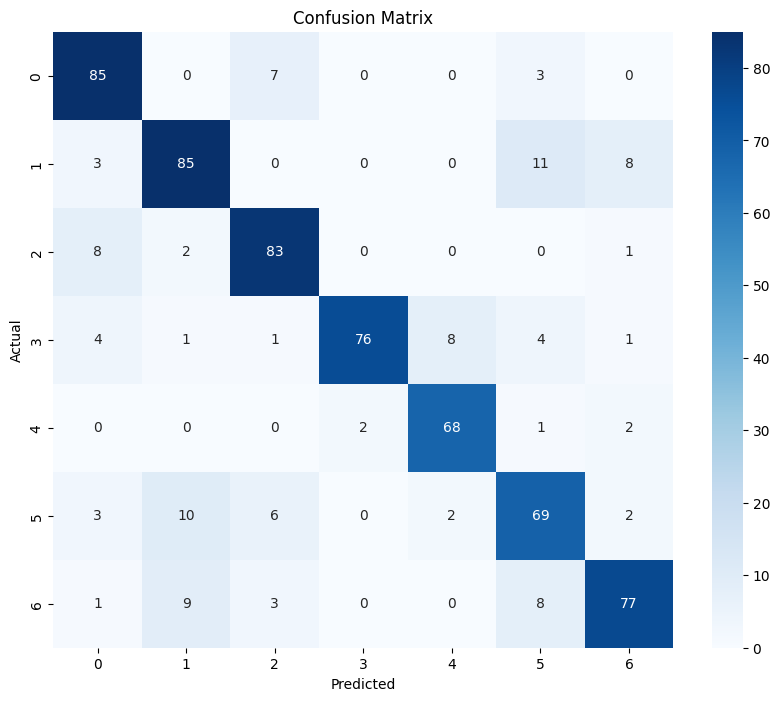

In [17]:
y_pred = model.predict(test_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes


cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Classification Report

In [18]:
from sklearn.metrics import classification_report

class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

01_stratocasters       0.82      0.89      0.85        95
    02_les_pauls       0.79      0.79      0.79       107
   03_telecaster       0.83      0.88      0.86        94
     04_explorer       0.97      0.80      0.88        95
     05_flying_v       0.87      0.93      0.90        73
           06_sg       0.72      0.75      0.73        92
           07_es       0.85      0.79      0.81        98

        accuracy                           0.83       654
       macro avg       0.84      0.83      0.83       654
    weighted avg       0.83      0.83      0.83       654



# Menampilkan 10 Prediksi Acak

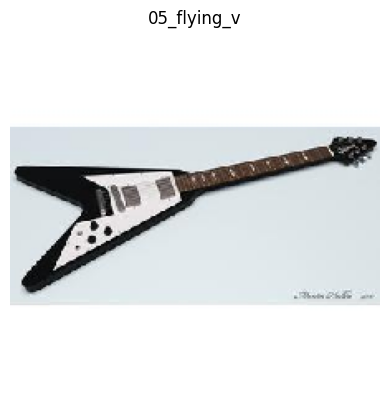

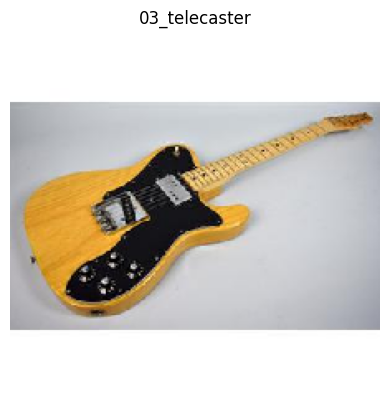

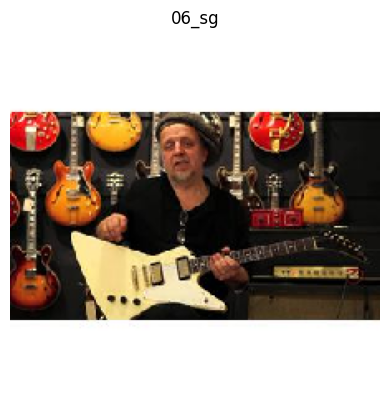

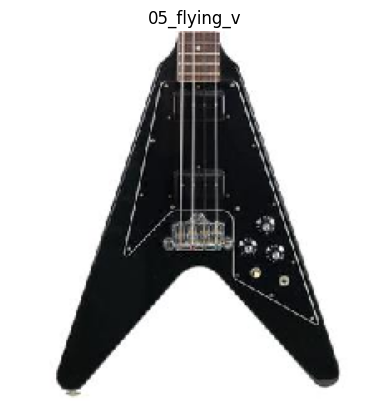

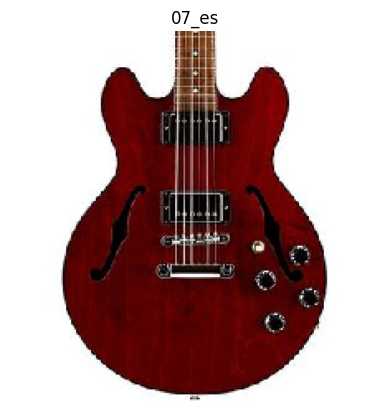

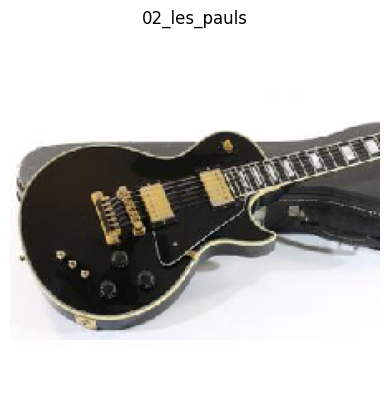

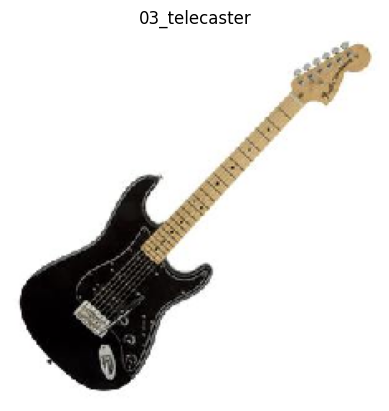

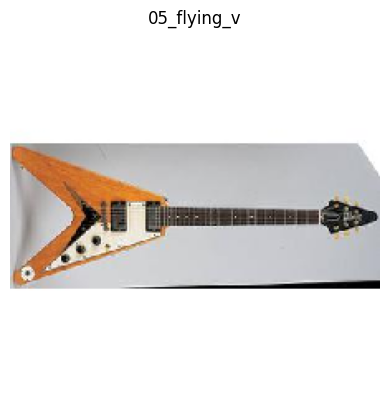

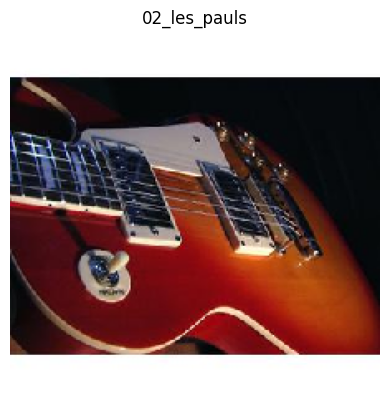

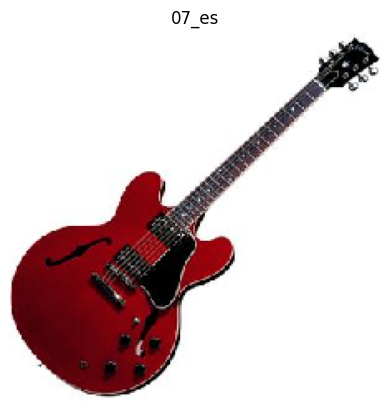

In [19]:
import random
from tensorflow.keras.preprocessing import image

class_names = list(
    test_generator.class_indices.keys()
)

for i in range(10):

    idx = random.randint(
        0,
        len(test_generator.filenames)-1
    )

    img_path = test_generator.filepaths[idx]

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = img_array/255.0
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    pred = model.predict(
        img_array,
        verbose=0
    )

    pred_class = class_names[
        np.argmax(pred)
    ]

    plt.imshow(img)
    plt.title(pred_class)
    plt.axis('off')
    plt.show()